Total baris data dibaca: 2507
Jumlah data training  : 2001
Jumlah data testing   : 501
Epoch 1/100


c:\Users\Dede\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0233 - mae: 0.0946 - val_loss: 0.0036 - val_mae: 0.0529
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.7703e-04 - mae: 0.0185 - val_loss: 7.0119e-04 - val_mae: 0.0211
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.3284e-04 - mae: 0.0141 - val_loss: 7.9066e-04 - val_mae: 0.0236
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.2238e-04 - mae: 0.0128 - val_loss: 3.6042e-04 - val_mae: 0.0145
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7712e-04 - mae: 0.0122 - val_loss: 3.1686e-04 - val_mae: 0.0135
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.6363e-04 - mae: 0.0122 - val_loss: 3.5878e-04 - val_mae: 0.0148
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.3943e-04 - mae: 0.0119 - val_loss: 3.4090e-04 - val_mae: 0.0144
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1981e-04 - mae: 0.0116 - val_loss: 2.9386e-04 - val_mae: 0.0131
Epoch 9/100
63/63 ━━


>>> Model dan Scaler Berhasil Disimpan! <<<
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

       HASIL EVALUASI MODEL
Mean Absolute Error (MAE) : Rp 62.35
Root Mean Squared Error (RMSE): Rp 77.05


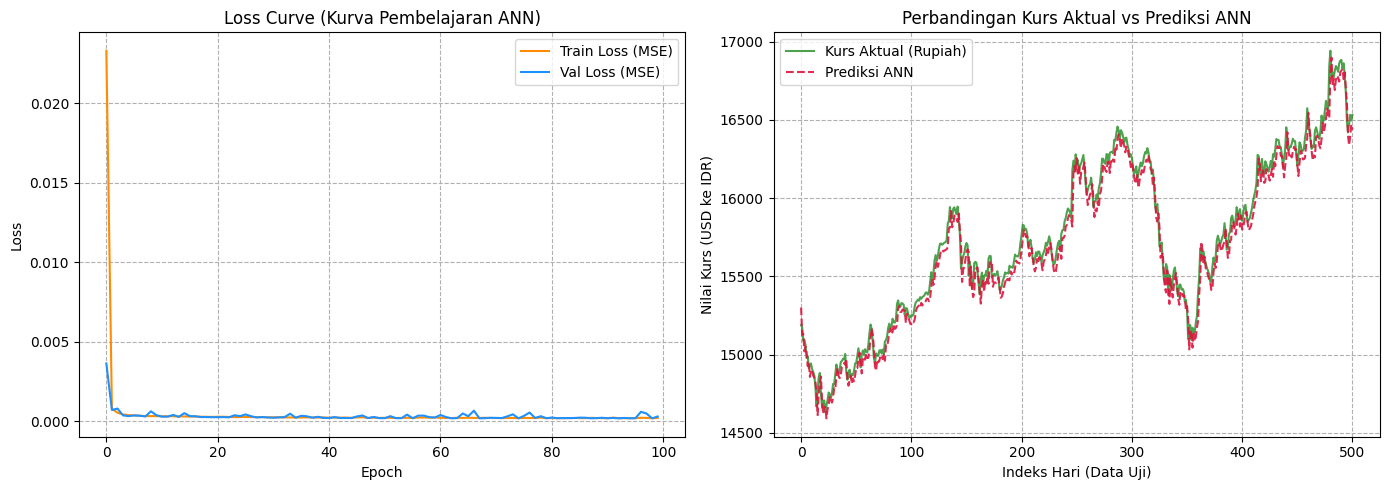

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# =====================================================================
# 1. LOAD DAN PREPROCESSING DATA
# =====================================================================

# Membaca data CSV baru yang menggunakan pemisah titik koma (sep=';')
df = pd.read_csv('../data/USD-IDR.csv', sep=';')

# Membersihkan spasi atau kolom kosong jika ada akibat pemisah di akhir baris
df = df.dropna(subset=['Kurs'])

# Balik urutan data agar kronologis (dari tahun 2015 ke 2025)
df = df.iloc[::-1].reset_index(drop=True)

# Memastikan kolom 'Kurs' terbaca sebagai angka (float/int)
df['Kurs'] = pd.to_numeric(df['Kurs'])

# Ambil data Kurs untuk proses normalisasi
data_kurs = df['Kurs'].values.reshape(-1, 1)

# Normalisasi data ke rentang 0 - 1
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_kurs)

# =====================================================================
# 2. MEMBUAT DATASET WINDOWING (Sifat Time Series)
# =====================================================================
# Menggunakan kurs 5 hari sebelumnya untuk memprediksi hari berikutnya
def create_windowed_dataset(data, window_size=5):
    X, Y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        Y.append(data[i + window_size, 0])
    return np.array(X), np.array(Y)

WINDOW_SIZE = 5
X, Y = create_windowed_dataset(data_scaled, WINDOW_SIZE)

# Memisahkan data secara berurutan (80% training, 20% testing)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
Y_train, Y_test = Y[:split_idx], Y[split_idx:]

print(f"Total baris data dibaca: {len(df)}")
print(f"Jumlah data training  : {X_train.shape[0]}")
print(f"Jumlah data testing   : {X_test.shape[0]}")

# =====================================================================
# 3. MEMBANGUN MODEL ANN (DENSE)
# =====================================================================
model = Sequential([
    Dense(32, activation='relu', input_shape=(WINDOW_SIZE,)), # Hidden layer 1
    Dense(16, activation='relu'),                             # Hidden layer 2
    Dense(1, activation='linear')                             # Output layer
])

# Kompilasi model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Melatih model
history = model.fit(
    X_train, Y_train, 
    epochs=100, 
    batch_size=32, 
    validation_data=(X_test, Y_test), 
    verbose=1
)

# =====================================================================
# 3.5. PROSES MENYIMPAN MODEL & SCALER (SISIHAN BARU DI SINI)
# =====================================================================
folder_model = '../model'
if not os.path.exists(folder_model):
    os.makedirs(folder_model)

# Menyimpan file h5 dan pkl ke dalam folder 'model'
model.save(os.path.join(folder_model, 'model_prediksi_kurs.h5'))
joblib.dump(scaler, os.path.join(folder_model, 'scaler_kurs.pkl'))
print("\n>>> Model dan Scaler Berhasil Disimpan! <<<")

# =====================================================================
# 4. PREDIKSI DAN EVALUASI (MAE, RMSE)
# =====================================================================

# Prediksi menggunakan data uji
Y_pred_scaled = model.predict(X_test)

# Denormalisasi (Kembalikan skala ke nilai Rupiah asli)
Y_test_actual = scaler.inverse_transform(Y_test.reshape(-1, 1))
Y_pred_actual = scaler.inverse_transform(Y_pred_scaled)

# Perhitungan MAE dan RMSE
mae = mean_absolute_error(Y_test_actual, Y_pred_actual)
rmse = np.sqrt(mean_squared_error(Y_test_actual, Y_pred_actual))

print("\n" + "="*30)
print("       HASIL EVALUASI MODEL")
print("="*30)
print(f"Mean Absolute Error (MAE) : Rp {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): Rp {rmse:.2f}")
print("="*30)

# =====================================================================
# 5. VISUALISASI HASIL ELEMEN EVALUASI (BAGIAN GRAFIK KAMU SUDAH KEMBALI)
# =====================================================================

plt.figure(figsize=(14, 5))

# A. Plot Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)', color='darkorange')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)', color='dodgerblue')
plt.title('Loss Curve (Kurva Pembelajaran ANN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--')

# B. Plot Hasil Prediksi vs Aktual
plt.subplot(1, 2, 2)
plt.plot(Y_test_actual, label='Kurs Aktual (Rupiah)', color='forestgreen', alpha=0.8)
plt.plot(Y_pred_actual, label='Prediksi ANN', color='crimson', linestyle='--', alpha=0.9)
plt.title('Perbandingan Kurs Aktual vs Prediksi ANN')
plt.xlabel('Indeks Hari (Data Uji)')
plt.ylabel('Nilai Kurs (USD ke IDR)')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()